In [8]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s5e11/sample_submission.csv
/kaggle/input/playground-series-s5e11/train.csv
/kaggle/input/playground-series-s5e11/test.csv


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    roc_auc_score, 
    roc_curve, 
    accuracy_score,
    f1_score
)
import warnings
warnings.filterwarnings("ignore")
from sklearn.linear_model import LogisticRegression
# from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


In [2]:
base_path = r'/kaggle/input/playground-series-s5e11/'
train_path = base_path + 'train.csv'
test_path = base_path + 'test.csv'

In [3]:
raw_df = pd.read_csv(train_path)

In [4]:
cat = [i for i in raw_df.columns if raw_df[i].dtype == "object"]
target = "loan_paid_back"
num = [i for i in raw_df.columns if i not in (cat + [target, "id"])]
base = [col for col in raw_df.columns if col not in ['id', target]]

print("Categorical Features: ", cat)
print("Numerical Features: ", num)
print("Target Feature: ", [target])
print("Base Features", base)

Categorical Features:  ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']
Numerical Features:  ['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate']
Target Feature:  ['loan_paid_back']
Base Features ['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate', 'gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']


In [ ]:
orig = []

for col in base:
    # MEAN
    mean_map = orig.groupby(col)[target].mean()
    new_mean_col_name = f"orig_mean_{col}"
    mean_map.name = new_mean_col_name
    
    train = raw_df.merge(mean_map, on=col, how='left')
    test = test.merge(mean_map, on=col, how='left')
    ORIG.append(new_mean_col_name)

    # COUNT
    new_count_col_name = f"orig_count_{col}"
    count_map = orig.groupby(col).size().reset_index(name=new_count_col_name)
    
    train = train.merge(count_map, on=col, how='left')
    test = test.merge(count_map, on=col, how='left')
    ORIG.append(new_count_col_name)

print(len(ORIG), 'Orig Features Created!!')

In [5]:
# Some added Featuure Engineering
# financial feature engineering
def feature_engnineering(raw_df):
    featured_df = raw_df.copy()
    featured_df['credit_utilization'] = featured_df['loan_amount'] / featured_df['annual_income']
    featured_df['interest_burden'] = featured_df['interest_rate'] * featured_df['loan_amount'] / 100
    featured_df['is_employed_flag'] = featured_df['employment_status'].apply(lambda x: 0 if x in ['Unemployed', 'Student', 'Retired'] else 1)
    featured_df['debt_intrest'] = featured_df['debt_to_income_ratio'] * featured_df['interest_rate'] / 100
    featured_df['credit_debt_interaction'] = featured_df['credit_score'] * featured_df['debt_to_income_ratio']
    
    # Example: Tagging high risk
    featured_df['high_risk_combo'] = (
        (featured_df['employment_status'].isin(['Unemployed', 'Student'])) &
        (featured_df['education_level'].isin(['High School', 'Other'])) &
        (featured_df['marital_status'].isin(['Single', 'Divorced', 'Widowed'])) &
        (featured_df['loan_purpose'].isin(['Medical', 'Education', 'Vacation', 'Other'])) &
        (featured_df['grade_subgrade'].str[0].isin(['D', 'E', 'F']))
    )
    return featured_df
    

In [6]:
feature_df = feature_engnineering(raw_df)
feature_df.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back,credit_utilization,interest_burden,is_employed_flag,debt_intrest,credit_debt_interaction,high_risk_combo
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0,0.086094,345.635014,1,0.011483,61.824,False
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0,0.207757,593.428520,1,0.021447,105.576,False
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0,0.343080,1659.702640,1,0.009467,67.318,False
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0,0.099929,753.879280,1,0.010465,34.645,False
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0,0.477883,1244.030303,1,0.005411,35.245,False


In [7]:
feature_df.columns

Index(['id', 'annual_income', 'debt_to_income_ratio', 'credit_score',
       'loan_amount', 'interest_rate', 'gender', 'marital_status',
       'education_level', 'employment_status', 'loan_purpose',
       'grade_subgrade', 'loan_paid_back', 'credit_utilization',
       'interest_burden', 'is_employed_flag', 'debt_intrest',
       'credit_debt_interaction', 'high_risk_combo'],
      dtype='object')

In [8]:
feature_num = ['annual_income', 'debt_to_income_ratio', 'credit_score',
               'loan_amount', 'interest_rate', 
               'credit_utilization', 'interest_burden', 'is_employed_flag',
               'debt_intrest', 'credit_debt_interaction', 'high_risk_combo'
              ]
feature_cat = ['gender', 'marital_status', 'education_level', 
               'employment_status', 'loan_purpose', 'grade_subgrade'
              ]
FEATURES = feature_num + feature_cat

In [9]:
train = feature_df.copy()
X = train[FEATURES]
y = train[target]
CATS = feature_cat.copy()
test = feature_engnineering(pd.read_csv(test_path))

In [10]:
from sklearn.model_selection import StratifiedKFold

N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

In [11]:
params = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'max_depth': 5,
    'colsample_bytree': 0.8,
    'subsample': 0.8,
    'n_estimators': 10000,
    'learning_rate': 0.01,
    'early_stopping_rounds': 100,
    'random_state': 42,
    'n_jobs': -1,
    'device': 'cuda',
    'enable_categorical': True,
}

In [34]:
oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(test))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    print(f'--- Fold {fold}/{N_SPLITS} ---')
    
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    X_test = test[FEATURES].copy()

    X_train[CATS] = X_train[CATS].astype('category')
    X_val[CATS] = X_val[CATS].astype('category')
    X_test[CATS] = X_test[CATS].astype('category')

    model = XGBClassifier(**params)
    
    model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              verbose=1000)

    val_preds = model.predict_proba(X_val)[:, 1]
    val_preds_bins = model.predict(X_val)
    oof_preds[val_idx] = val_preds
    
    fold_score = roc_auc_score(y_val, val_preds)
    print(f'Fold {fold} AUC: {fold_score:.4f}')
    test_preds += model.predict_proba(X_test)[:, 1] / N_SPLITS
    print(classification_report(y_val, val_preds_bins))

overall_auc = roc_auc_score(y, oof_preds)
print(f'====================')
print(f'Overall OOF AUC: {overall_auc:.4f}')
print(f'====================')

--- Fold 1/5 ---


/tmp/ipykernel_37/737165867.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[CATS] = X_train[CATS].astype('category')
/tmp/ipykernel_37/737165867.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val[CATS] = X_val[CATS].astype('category')


[0]	validation_0-auc:0.90498


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [04:20:42] WARNING: /workspace/src/context.cc:44: No visible GPU is found, setting device to CPU.
  warnings.warn(smsg, UserWarning)


[1000]	validation_0-auc:0.91819
[2000]	validation_0-auc:0.92049
[3000]	validation_0-auc:0.92145
[4000]	validation_0-auc:0.92185
[5000]	validation_0-auc:0.92203
[5238]	validation_0-auc:0.92205
Fold 1 AUC: 0.9221
[1000]	validation_0-auc:0.91751
[2000]	validation_0-auc:0.91995
[3000]	validation_0-auc:0.92099
[4000]	validation_0-auc:0.92142
[5000]	validation_0-auc:0.92163
[5592]	validation_0-auc:0.92169
Fold 2 AUC: 0.9217
              precision    recall  f1-score   support

         0.0       0.88      0.61      0.72     23900
         1.0       0.91      0.98      0.94     94899

    accuracy                           0.90    118799
   macro avg       0.90      0.79      0.83    118799
weighted avg       0.90      0.90      0.90    118799

--- Fold 3/5 ---


...

[1000]	validation_0-auc:0.91600
[2000]	validation_0-auc:0.91835
[3000]	validation_0-auc:0.91930
[4000]	validation_0-auc:0.91969
[4990]	validation_0-auc:0.91984
Fold 3 AUC: 0.9199
              precision    recall  f1-score   support

         0.0       0.88      0.61      0.72     23900
         1.0       0.91      0.98      0.94     94899

    accuracy                           0.90    118799
   macro avg       0.89      0.79      0.83    118799
weighted avg       0.90      0.90      0.90    118799

--- Fold 4/5 ---


/tmp/ipykernel_37/737165867.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[CATS] = X_train[CATS].astype('category')
/tmp/ipykernel_37/737165867.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val[CATS] = X_val[CATS].astype('category')


[0]	validation_0-auc:0.90403


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [04:36:01] WARNING: /workspace/src/context.cc:44: No visible GPU is found, setting device to CPU.
  warnings.warn(smsg, UserWarning)


[1000]	validation_0-auc:0.91707
[2000]	validation_0-auc:0.91937
[3000]	validation_0-auc:0.92029
[4000]	validation_0-auc:0.92060
[5000]	validation_0-auc:0.92075
[5090]	validation_0-auc:0.92075
Fold 4 AUC: 0.9207
[1000]	validation_0-auc:0.91668
[2000]	validation_0-auc:0.91898
[3000]	validation_0-auc:0.91987
[4000]	validation_0-auc:0.92019
[4300]	validation_0-auc:0.92021
Fold 5 AUC: 0.9202
              precision    recall  f1-score   support

         0.0       0.89      0.61      0.72     23900
         1.0       0.91      0.98      0.94     94898

    accuracy                           0.91    118798
   macro avg       0.90      0.79      0.83    118798
weighted avg       0.90      0.91      0.90    118798

Overall OOF AUC: 0.9209


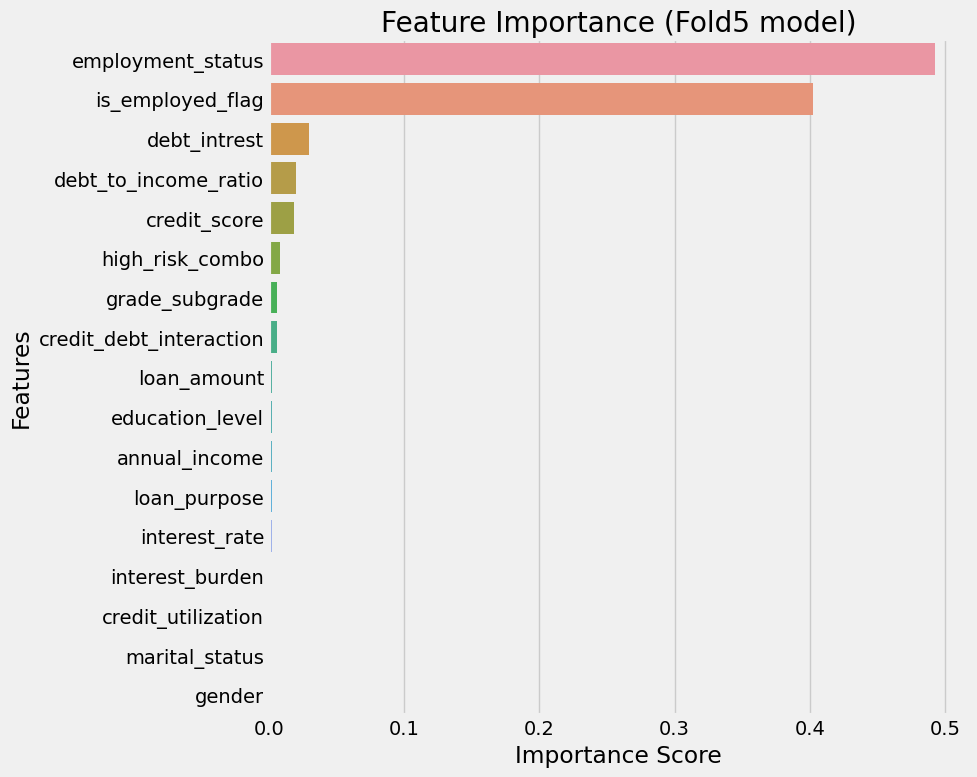

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

feature_importances = model.feature_importances_

importance_df = pd.DataFrame({
    'feature': FEATURES, 
    'importance': feature_importances
})

importance_df = importance_df.sort_values('importance', ascending=False)

plt.style.use('fivethirtyeight')
plt.figure(figsize=(10, 8))
sns.barplot(x='importance', 
            y='feature', 
            data=importance_df.head(50)) 
plt.title('Feature Importance (Fold5 model)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [39]:
pd.DataFrame({'id': train.id, target: oof_preds}).to_csv(f'oof_xgb_cv_{overall_auc}.csv', index=False)
pd.DataFrame({'id': test.id, target: test_preds}).to_csv(f'test_xgb_cv_{overall_auc}.csv', index=False)

In [4]:
import pandas as pd
pd.read_csv(test_path)

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade
0,593994,28781.05,0.049,626,11461.42,14.73,Female,Single,High School,Employed,Other,D5
1,593995,46626.39,0.093,732,15492.25,12.85,Female,Married,Master's,Employed,Other,C1
2,593996,54954.89,0.367,611,3796.41,13.29,Male,Single,Bachelor's,Employed,Debt consolidation,D1
3,593997,25644.63,0.110,671,6574.30,9.57,Female,Single,Bachelor's,Employed,Debt consolidation,C3
4,593998,25169.64,0.081,688,17696.89,12.80,Female,Married,PhD,Employed,Business,C1
...,...,...,...,...,...,...,...,...,...,...,...,...
254564,848558,92835.97,0.068,744,29704.00,13.48,Female,Single,Bachelor's,Employed,Debt consolidation,B2
254565,848559,48846.47,0.091,634,20284.33,9.58,Female,Married,High School,Employed,Debt consolidation,D4
254566,848560,20668.52,0.096,718,26387.55,9.00,Male,Single,Master's,Employed,Debt consolidation,C4
254567,848561,34105.09,0.094,739,11107.36,9.81,Male,Single,Bachelor's,Employed,Business,C2


In [6]:
submission = pd.read_csv('/kaggle/working/test_xgb_cv_0.9209118476492721.csv')

In [7]:
submission.to_csv("submission.csv", index = False)

Trying LGBM

In [12]:
lgbm_params = {
    'objective': 'binary',          # same as 'binary:logistic' in XGBoost
    'metric': 'auc',                # equivalent to eval_metric
    'max_depth': 5,
    'colsample_bytree': 0.8,        # same meaning
    'subsample': 0.8,               # same meaning
    'n_estimators': 10000,
    'learning_rate': 0.01,
    'random_state': 42,
    'n_jobs': -1,
    # 'device': 'gpu',                # LightGBM uses 'gpu' instead of 'cuda'
    'early_stopping_round': 100,    # note: singular form ('round'), or pass to fit()
    'enable_categorical': True,     # works in LightGBM 3.3+ for native categorical support
}


In [ ]:
from lightgbm import log_evaluation

oof_preds = np.zeros(len(X))
test_preds = np.zeros(len(test))

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    print(f'--- Fold {fold}/{N_SPLITS} ---')
    
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    X_test = test[FEATURES].copy()

    X_train[CATS] = X_train[CATS].astype('category')
    X_val[CATS] = X_val[CATS].astype('category')
    X_test[CATS] = X_test[CATS].astype('category')

    model = LGBMClassifier(**lgbm_params)
    
    model.fit(X_train, y_train,
            eval_set=[(X_val, y_val)],
            callbacks=[log_evaluation(period=1000)],
            eval_metric='auc',  # prints every 1000 rounds
        )

    val_preds = model.predict_proba(X_val)[:, 1]
    val_preds_bins = model.predict(X_val)
    oof_preds[val_idx] = val_preds
    
    fold_score = roc_auc_score(y_val, val_preds)
    print(f'Fold {fold} AUC: {fold_score:.4f}')
    test_preds += model.predict_proba(X_test)[:, 1] / N_SPLITS
    print(classification_report(y_val, val_preds_bins))

overall_auc = roc_auc_score(y, oof_preds)
print(f'====================')
print(f'Overall OOF AUC: {overall_auc:.4f}')
print(f'====================')

--- Fold 1/5 ---
[LightGBM] [Warning] Unknown parameter: enable_categorical
[LightGBM] [Warning] Unknown parameter: enable_categorical
[LightGBM] [Info] Number of positive: 379595, number of negative: 95600
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.061611 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2357
[LightGBM] [Info] Number of data points in the train set: 475195, number of used features: 17
[LightGBM] [Warning] Unknown parameter: enable_categorical
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.798819 -> initscore=1.378932
[LightGBM] [Info] Start training from score 1.378932
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

In [ ]:
pd.DataFrame({'id': train.id, target: oof_preds}).to_csv(f'oof_llb_cv_{overall_auc}.csv', index=False)
pd.DataFrame({'id': test.id, target: test_preds}).to_csv(f'test_lgb_cv_{overall_auc}.csv', index=False)